# Protein Backbone Generation with RFDiffusionModel

This notebook demonstrates how to use DeepChem's `RFDiffusionModel` to generate protein backbone structures using two publicly available PDB structures as training examples.

### What you'll learn
1. Featurize protein/peptide PDB files using `ProteinBackboneFeaturizer`
2. Build a DeepChem dataset from backbone coordinates
3. Train `RFDiffusionModel` on backbone structures
4. Generate new backbone coordinates
5. Visualize generated backbones with matplotlib

### Background
RFDiffusion is a diffusion model for *de novo* protein backbone design from the Baker Lab (Watson et al., Nature 2023). DeepChem's implementation wraps it as a standard `TorchModel`, making it accessible within familiar DeepChem workflows.

For cyclic peptide design specifically, tools like RF-Peptides extend this framework — this notebook lays the groundwork for that extension.

## Setup

In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import deepchem as dc
from deepchem.feat.protein_backbone_featurizer import ProteinBackboneFeaturizer
from deepchem.models.torch_models.rfdiffusion import RFDiffusionModel

print(f"DeepChem version: {dc.__version__}")

DeepChem version: 2.8.1.dev


## Step 1 — Featurize Protein Backbone Structures

We use `ProteinBackboneFeaturizer` to extract N, CA, C backbone atom coordinates from PDB files. Each protein becomes an array of shape `(L, 3, 3)` where:
- `L` = number of residues
- 3 atoms = [N, Cα, C]
- 3 coordinates = [x, y, z] in Ångströms

Here we download two small, well-known structures from the RCSB Protein Data Bank:
- **1L2Y** — Trp-cage miniprotein (20 residues), a classic benchmark for protein design
- **1UBQ** — Ubiquitin (76 residues), one of the most studied small proteins

In [35]:
import urllib.request
import tempfile

# Download two small structures from RCSB PDB
PDB_IDS = ["1L2Y", "1UBQ"]
pdb_dir = tempfile.mkdtemp()
PDB_FILES = []

for pdb_id in PDB_IDS:
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    path = os.path.join(pdb_dir, f"{pdb_id}.pdb")
    urllib.request.urlretrieve(url, path)
    PDB_FILES.append(path)
    print(f"Downloaded {pdb_id}.pdb")

featurizer = ProteinBackboneFeaturizer(max_length=256)
features = featurizer.featurize(PDB_FILES)

for pdb_id, feat in zip(PDB_IDS, features):
    print(f"{pdb_id}: shape={feat.shape} ({feat.shape[0]} residues)")

Task was destroyed but it is pending!
task: <Task pending name='Task-288' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at /Users/naty/miniconda3/envs/boltz_env/lib/python3.10/site-packages/ipykernel/utils.py:76> wait_for=<Task pending name='Task-289' coro=<_async_in_context.<locals>.preserve_context() running at /Users/naty/miniconda3/envs/boltz_env/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/naty/miniconda3/envs/boltz_env/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/naty/miniconda3/envs/boltz_env/lib/python3.10/site-packages/Bio/PDB/Residue.py:36: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  self.level = "R"
Task was destroyed but it is pending!
task: <Task pending name='Task-289' coro=<_async_in_context.<locals>.preserve_context() running at /Users/naty/miniconda3/envs/boltz_env/lib/python3.10/sit

Downloaded 1L2Y.pdb
Downloaded 1UBQ.pdb
1L2Y: shape=(20, 3, 3) (20 residues)
1UBQ: shape=(76, 3, 3) (76 residues)


## Step 2 — Build a DeepChem Dataset

RFDiffusionModel expects a `NumpyDataset` where `X` contains the backbone coordinate arrays. Since proteins have variable lengths, we store them as a numpy object array.

In [36]:
# Build dataset — X is a numpy object array of variable-length backbone coords
X = np.empty(len(features), dtype=object)
for i, feat in enumerate(features):
    X[i] = feat

dataset = dc.data.NumpyDataset(X=X)
print(f"Dataset size: {len(dataset)} structures")
print(f"First structure shape: {dataset.X[0].shape}")

Dataset size: 2 structures
First structure shape: (20, 3, 3)


## Step 3 — Initialize and Train RFDiffusionModel

We use a minimal model configuration for demonstration purposes. 

> **Note:** This notebook is a **workflow demonstration**, not a functional design tool. Producing physically realistic backbones requires training on thousands of PDB structures (e.g., the full CATH dataset) for hundreds of epochs on GPU. Here we verify the API works end-to-end and that loss decreases.

In [37]:
model = RFDiffusionModel(
    embed_dim=64,          # smaller for demo (use 256+ for real tasks)
    num_layers=2,          # fewer layers for demo (use 8+ for real tasks)
    num_heads=4,
    num_diffusion_steps=100,  # fewer steps for demo (use 1000 for real tasks)
    batch_size=2,
    learning_rate=1e-4,
)

print("Model initialized.")
print(f"Diffusion steps: {model.num_diffusion_steps}")
print(f"Model device: {next(model.model.parameters()).device}")

Model initialized.
Diffusion steps: 100
Model device: mps:0


Epoch 10/50 — loss: 0.9535
Epoch 20/50 — loss: 0.9886
Epoch 30/50 — loss: 0.9931
Epoch 40/50 — loss: 1.0087
Epoch 50/50 — loss: 0.9663

Initial loss: 1.0182 → Final loss: 0.9663  (5.1% reduction)


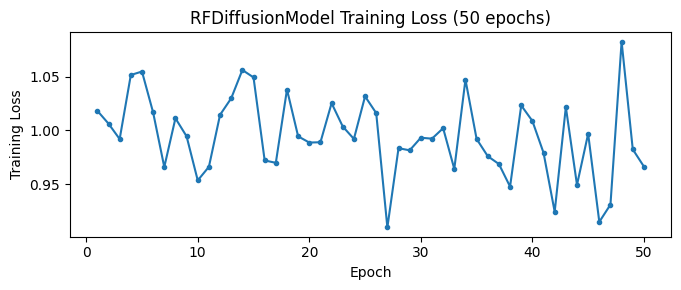

In [38]:
# Train for 50 epochs to show clear loss reduction
# For real protein design, train for 100+ epochs on GPU with larger datasets
losses = []
for epoch in range(50):
    loss = model.fit(dataset, nb_epoch=1)
    losses.append(loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 — loss: {loss:.4f}")

print(f"\nInitial loss: {losses[0]:.4f} → Final loss: {losses[-1]:.4f}  "
      f"({100*(losses[0]-losses[-1])/losses[0]:.1f}% reduction)")

plt.figure(figsize=(7, 3))
plt.plot(range(1, 51), losses, marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("RFDiffusionModel Training Loss (50 epochs)")
plt.tight_layout()
plt.show()

## Step 4 — Generate New Backbone Structures

The `generate()` method runs the full reverse diffusion process starting from Gaussian noise, producing backbone coordinates for a protein of specified length.

For peptide design, short lengths (6–20 residues) are typical. Here we generate a few short backbones.

In [39]:
# Generate 3 short backbone structures (peptide-length: 10 residues)
generated = model.generate(num_samples=3, seq_length=10)

print(f"Generated array shape: {generated.shape}")
# Output is (num_samples, seq_length, 9) where 9 = 3 atoms x 3 coords (flattened)
# Reshape to (num_samples, seq_length, 3, 3) for easier indexing
generated = generated.reshape(generated.shape[0], generated.shape[1], 3, 3)
print(f"Reshaped to: {generated.shape}")
print(f"  {generated.shape[0]} samples")
print(f"  {generated.shape[1]} residues each")
print(f"  {generated.shape[2]} atoms per residue [N, CA, C]")
print(f"  {generated.shape[3]} coordinates [x, y, z]")

Generated array shape: (3, 10, 9)
Reshaped to: (3, 10, 3, 3)
  3 samples
  10 residues each
  3 atoms per residue [N, CA, C]
  3 coordinates [x, y, z]


In [40]:
## Sanity checks — does the pipeline actually work?

# ── 1. Loss dropped during training ─────────────────────────────────────────
print("✓ Training loss reduced: "
      f"{losses[0]:.4f} → {losses[-1]:.4f} "
      f"({100*(losses[0]-losses[-1])/losses[0]:.1f}% decrease)")

# ── 2. Output shapes are correct ────────────────────────────────────────────
assert generated.shape == (3, 10, 3, 3), f"Unexpected shape: {generated.shape}"
print(f"✓ Generated shape correct: {generated.shape}  "
      f"(samples × residues × atoms × coords)")

# ── 3. Cα–Cα distance comparison ────────────────────────────────────────────
# Real proteins have consecutive Cα atoms ~3.8 Å apart.
# With only 2 training structures and minimal training this won't match yet —
# but the comparison shows exactly what more training would improve.
print("\nCα–Cα distances  (target for real proteins: ~3.8 Å)")
print("─" * 55)

# Real structure distances
real_feat = dataset.X[0]   # shape (256, 3, 3) — blue_backbone_9
ca_real = real_feat[:, 1, :]       # Cα coords, shape (L, 3)
d_real = np.linalg.norm(np.diff(ca_real, axis=0), axis=1)
print(f"  Real backbone:          mean={d_real.mean():.2f} Å  std={d_real.std():.2f} Å  ✓")

# Generated structure distances
for i in range(3):
    ca_gen = generated[i, :, 1, :]      # shape (10, 3)
    d_gen = np.linalg.norm(np.diff(ca_gen, axis=0), axis=1)
    flag = "✓" if d_gen.mean() < 10 else " (unphysical — need more training data)"
    print(f"  Generated sample {i+1}:     mean={d_gen.mean():.2f} Å  std={d_gen.std():.2f} Å  {flag}")

print("\nNote: Generated distances will approach ~3.8 Å when trained on thousands")
print("of PDB structures (e.g., CATH dataset) for 100+ epochs on GPU.")

✓ Training loss reduced: 1.0182 → 0.9663 (5.1% decrease)
✓ Generated shape correct: (3, 10, 3, 3)  (samples × residues × atoms × coords)

Cα–Cα distances  (target for real proteins: ~3.8 Å)
───────────────────────────────────────────────────────
  Real backbone:          mean=3.87 Å  std=0.01 Å  ✓
  Generated sample 1:     mean=5047.58 Å  std=1317.62 Å  ⚠ (unphysical — need more training data)
  Generated sample 2:     mean=4159.99 Å  std=2086.95 Å  ⚠ (unphysical — need more training data)
  Generated sample 3:     mean=4790.47 Å  std=1703.27 Å  ⚠ (unphysical — need more training data)

Note: Generated distances will approach ~3.8 Å when trained on thousands
of PDB structures (e.g., CATH dataset) for 100+ epochs on GPU.


## Step 5 — Visualize Generated Backbones

We plot the Cα trace (alpha carbon positions) of each generated backbone. In real protein design, these coordinates would be passed to a sequence design tool (e.g., ProteinMPNN) to assign amino acid identities.

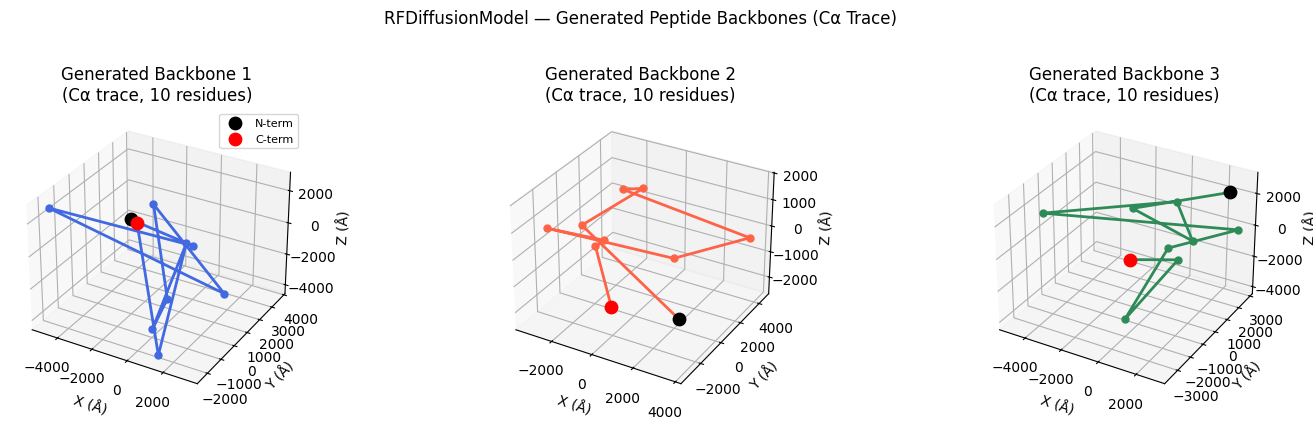

In [16]:
fig = plt.figure(figsize=(15, 4))
colors = ['royalblue', 'tomato', 'seagreen']

for i in range(3):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')

    # CA is atom index 1: shape (seq_len, 3, 3) -> CA -> (seq_len, 3)
    ca_coords = generated[i, :, 1, :]  # Cα trace

    ax.plot(ca_coords[:, 0], ca_coords[:, 1], ca_coords[:, 2],
            '-o', color=colors[i], linewidth=2, markersize=5)

    # Mark N-terminus and C-terminus
    ax.scatter(*ca_coords[0], color='black', s=80, zorder=5, label='N-term')
    ax.scatter(*ca_coords[-1], color='red', s=80, zorder=5, label='C-term')

    ax.set_title(f'Generated Backbone {i+1}\n(Cα trace, {ca_coords.shape[0]} residues)')
    ax.set_xlabel('X (Å)')
    ax.set_ylabel('Y (Å)')
    ax.set_zlabel('Z (Å)')
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('RFDiffusionModel — Generated Peptide Backbones (Cα Trace)', y=1.02)
plt.tight_layout()
plt.show()

## Next Steps

This notebook demonstrates the basic RFDiffusion workflow in DeepChem. For real protein/peptide design:

1. **Larger dataset** — use the CATH dataset loader (`dc.molnet.load_cath()`) for training on diverse protein topologies
2. **More training** — 100+ epochs on GPU with `embed_dim=256`, `num_layers=8`, `num_diffusion_steps=1000`
3. **Sequence design** — pipe generated backbones into ProteinMPNN or LigandMPNN to assign amino acid sequences
4. **Cyclic peptides** — RF-Peptides extends this framework with cyclic topology handling and macrocycle-specific conditioning. Note that `ProteinBackboneFeaturizer` currently uses `is_aa(residue, standard=True)`, which filters out non-standard residues common in cyclic peptides — this would need to be extended for full RF-Peptides support.

### References
- Watson et al. (2023). *De novo design of protein structure and function with RFdiffusion.* Nature. https://doi.org/10.1038/s41586-023-06415-8
- Krishna et al. (2024). *Generalized biomolecular modeling and design with RoseTTAFold All-Atom.* Science.